# Descriptive statistics about ESCO and O*NET skills and occupations
Felix Zaussinger | 06.04.2022

## Core Analysis Goal(s)
1. Find out how green & brown skills/tasks are distributed across occupations:
- What are the greenest/brownest occupations according to ESCO? Do they make any sense?
- What are the greenest occupations according to O*NET? How do they compare with
those in ESCO?
- How well do the greenness scores correlate?
- Does differentiating essential & optional ESCO skills make a big or marginal
difference?
2. What tasks/skills are important for the greennest/brownest occupations? How do
they compare between ESCO & O*NET?
3.

## Key Insight(s)
1.
2.
3.

In [41]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels as sm

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils, stats_utils, plotting_utils
from src.data.framework import Esco
# import mapping_career_causeways

plt.style.use({'figure.facecolor': 'white'})

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("paper")
sns.set(rc={'figure.figsize': (5, 5.), 'figure.facecolor': 'white'})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths(fn_config_path="paths_config.yml")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Configuration files

In [42]:
fn_config_path = "paths_config.yml"
fn_config_data = "data_config.yml"
fn_config_model = "model_config.yml"
fn_config_vis = "vis_config.yml"

## 1. Inspection of ESCO data

In [43]:
of = Esco()

In [44]:
smd = of.combine_skills_metadata(variable_selection=None)

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [45]:
omd = of.combine_occupation_metadata(skills_metadata=smd)

**Is there a logical cutoff point for green and brown skills (machine score)?**

<AxesSubplot:>

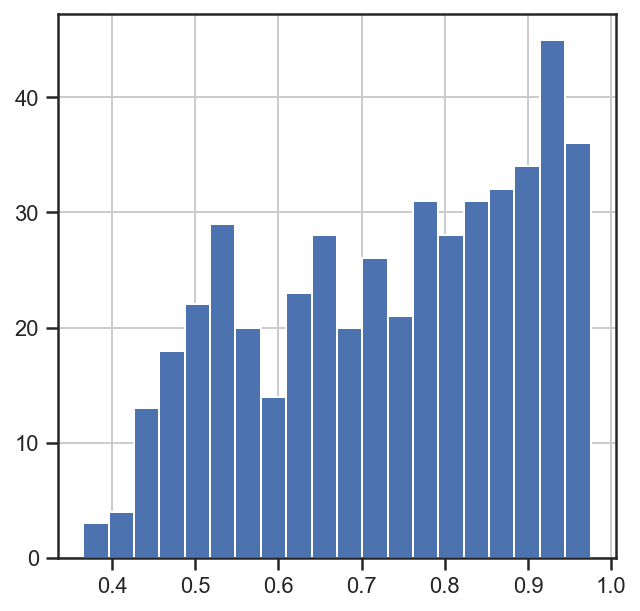

In [46]:
of.skills_brown.machineScore_brown.hist(bins=20)

<AxesSubplot:>

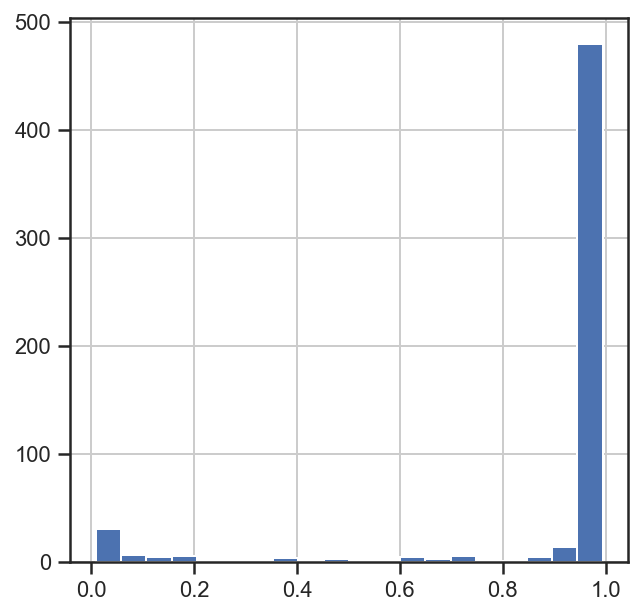

In [47]:
gs = of.skills_green.loc[of.skills_green.machineScore_green != "Expert-driven"]
gs.machineScore_green.hist(bins=20)

**Is there a logical cutoff point for green and brown occupations (share-based)?**

<AxesSubplot:>

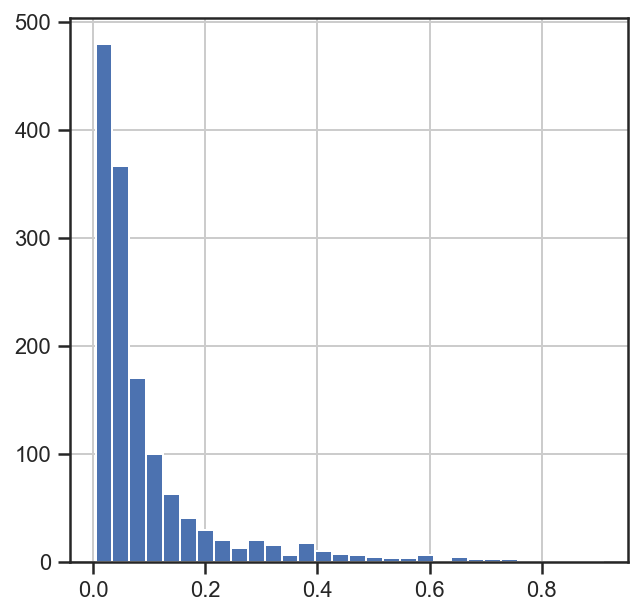

In [48]:
omd.share_green_esco.replace(0, np.nan).hist(bins=30)

<AxesSubplot:>

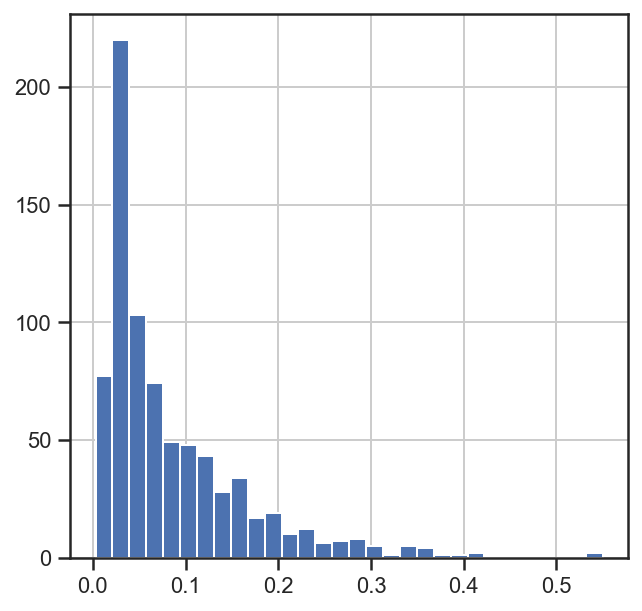

In [49]:
omd.share_brown_esco.replace(0, np.nan).hist(bins=30)

In [50]:
of.crosswalk_onet_esco_mcc_full

,id,concept_uri,preferred_label,isco_level_4,onet_code,onet_occupation
0,0,http://data.europa.eu/esco/occupation/00030d09...,technical director,2166,27-1011.00,art directors
1,1,http://data.europa.eu/esco/occupation/000e93a3...,metal drawing machine operator,8121,51-4021.00,"extruding and drawing machine setters, operato..."
2,2,http://data.europa.eu/esco/occupation/0019b951...,precision device inspector,7543,51-9061.00,"inspectors, testers, sorters, samplers, and we..."
3,3,http://data.europa.eu/esco/occupation/0022f466...,air traffic safety technician,3155,17-3023.01,electronics engineering technicians
4,4,http://data.europa.eu/esco/occupation/002da35b...,hospitality revenue manager,2431,13-1161.00,market research analysts and marketing special...
...,...,...,...,...,...,...
2937,2937,http://data.europa.eu/esco/occupation/ff656b3a...,demographer,2120,15-2041.00,statisticians
2938,2938,http://data.europa.eu/esco/occupation/ff8d4065...,sorter labourer,9612,51-9199.01,recycling and reclamation workers
2939,2939,http://data.europa.eu/esco/occupation/ffa4dd5d...,armoured car guard,5414,33-9032.00,security guards
2940,2940,http://data.europa.eu/esco/occupation/ffade2f4...,civil service administrative officer,2422,11-3011.00,administrative services managers


### 1.1 ESCO Skills Pillar

In [51]:
smd.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 13891 entries, 0 to 13890
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   conceptType                  13891 non-null  object 
 1   conceptUri                   13891 non-null  object 
 2   skillType                    13890 non-null  object 
 3   reuseLevel                   13891 non-null  object 
 4   preferredLabel               13891 non-null  object 
 5   altLabels                    13257 non-null  object 
 6   hiddenLabels                 109 non-null    object 
 7   status                       13891 non-null  object 
 8   modifiedDate                 13891 non-null  object 
 9   scopeNote                    226 non-null    object 
 10  definition                   3 non-null      object 
 11  inScheme                     13891 non-null  object 
 12  description                  13891 non-null  object 
 13  broaderConceptUr

#### Green, brown and neutral skills

Select GBN skill classification version (Raw ESCO version vs. ETH version)

In [52]:
clsf = "esco"

skill_cols_nf = ["skill_green_{}", "skill_brown_{}", "skill_neutral_{}"]
skill_cols = [col.format(clsf) for col in skill_cols_nf]

skill_clsf_col = "skill_classification_{}".format(clsf)

Number and share of skills by GBN classification

In [53]:
n_skills_by_gbn = smd[skill_cols].sum().to_frame("n")
n_skills_by_gbn.loc[:, "share"] = n_skills_by_gbn / len(smd)
n_skills_by_gbn

,n,share
skill_green_esco,570,0.041034
skill_brown_esco,477,0.034339
skill_neutral_esco,12844,0.924627


#### Skill type
- knowledge: body of facts, principles theories and practices related to a
field/work/study
- skills: ability to apply knowledge to complete tasks
- competence: proven ability to use knowledge and skills

In [54]:
smd.skillType.unique()

array(['skill/competence', 'knowledge', nan], dtype=object)

Q1: How are g/b/n skills distributed across skill types?

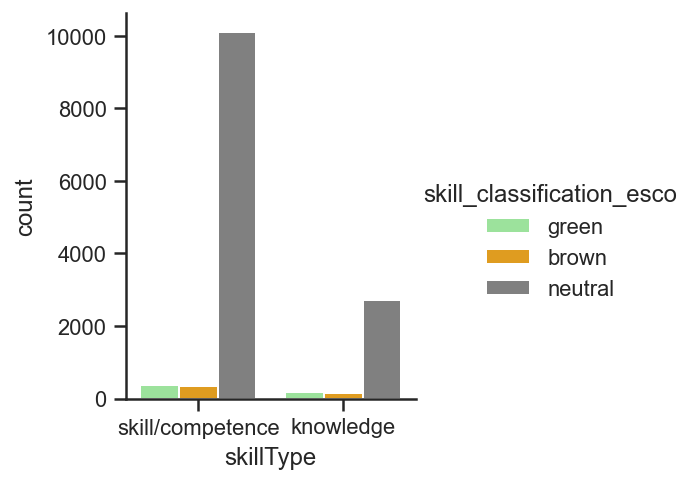

In [55]:
sns.catplot(
    data=smd,
    kind="count",
    x="skillType",
    hue=skill_clsf_col,
    height=3.5,
    hue_order=["green", "brown", "neutral"],
    palette=["lightgreen", "orange", "grey"],
)

plt.show()

In [56]:
smd.groupby("skillType")[skill_cols].sum()

,skill_green_esco,skill_brown_esco,skill_neutral_esco
skillType,,,
knowledge,186,141,2730
skill/competence,384,336,10113


#### Reuse level

The ESCO reuse level can be used to derive:
- how transversal a skill is
- a rough differentiation between skills and tasks

Skills probably correspond to cross-sector & transversal and tasks to sector-specific
and occupation-specific.

In [57]:
smd.reuseLevel.unique()

array(['sector-specific', 'occupation-specific', 'cross-sector',
       'transversal'], dtype=object)

Q: How are g/b/n skills distributed across reuse levels?

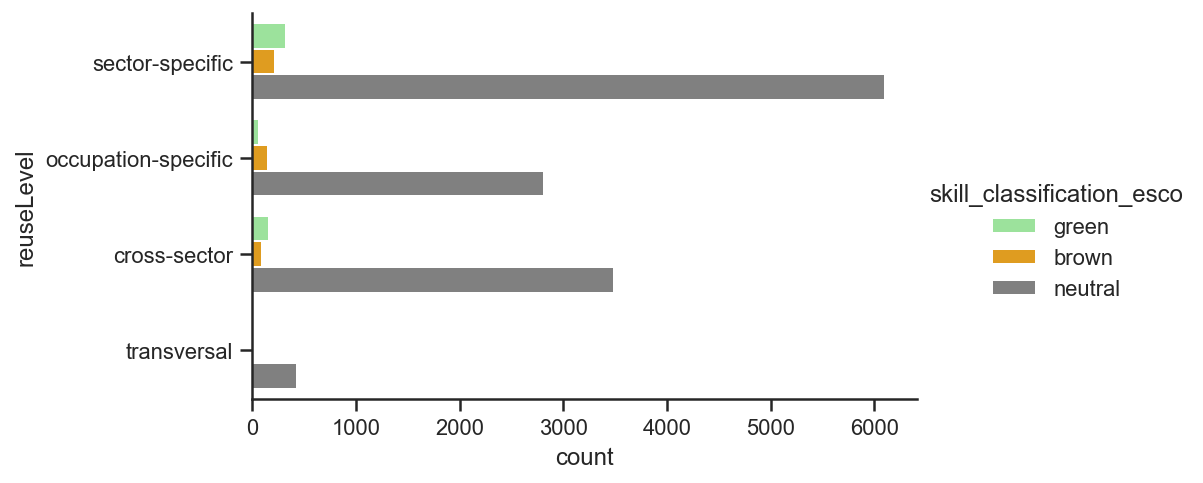

In [58]:
sns.catplot(
    data=smd,
    kind="count",
    y="reuseLevel",
    hue=skill_clsf_col,
    height=3.5,
    aspect=2,
    hue_order=["green", "brown", "neutral"],
    palette=["lightgreen", "orange", "grey"],
    orient="v"
)

Answer: green skills may be more transversal and thus enable smoother job
transitions.
- green skills more sector-specific and cross-sectoral
- brown skills more occupation-specific

Q: Are green skills more central/core than brown or neutral skills?

In [59]:
# drop nans
smd_clean = smd.dropna(subset=["coreness"])
len(smd_clean)

13379

In [60]:
df_pbsr = stats_utils.pbsr(smd_clean, "coreness", skill_cols)
df_pbsr

,pbsr,pval
skill_green_esco,0.052720,1.049824e-09
skill_brown_esco,-0.042455,8.996940e-07
skill_neutral_esco,-0.005557,5.204347e-01


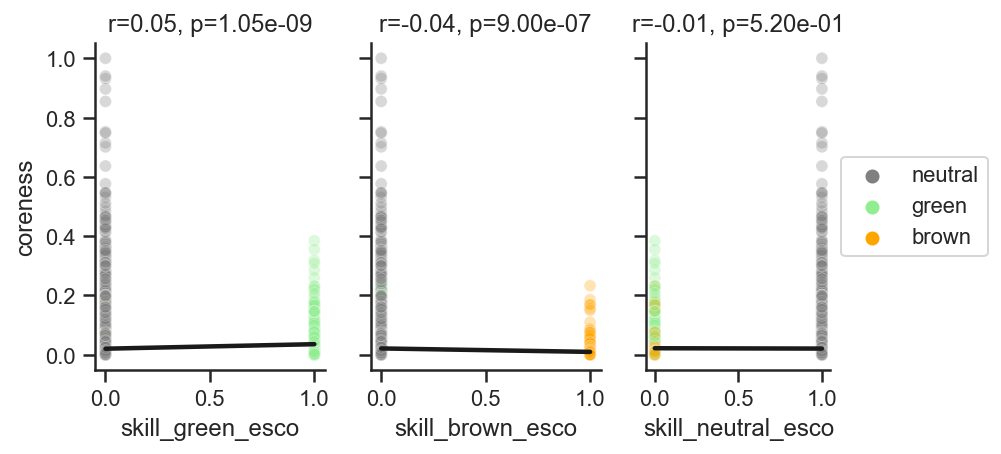

In [61]:
f, axes = plt.subplots(1, 3, sharey=True, sharex=True, figsize=(7, 3))

for i, xvar in enumerate(skill_cols):

    pbsr = df_pbsr.loc[xvar, :]
    r = pbsr.loc["pbsr"]
    pval = pbsr.loc["pval"]

    sns.scatterplot(
        data=smd_clean,
        x=xvar,
        y="coreness",
        hue=skill_clsf_col,
        hue_order=["neutral", "green", "brown"],
        palette=["grey", "lightgreen", "orange"],
        alpha=0.3,
        ax=axes[i],
        legend=True if i == len(skill_cols) - 1 else False
    )

    sns.regplot(
        data=smd_clean,
        x=xvar,
        y="coreness",
        scatter=False,
        color="k",
        ax=axes[i],
    )

    axes[i].set_title("r={:.2f}, p={:.2e}".format(r, pval))

    if i == len(skill_cols) - 1:
        plotting_utils.move_legend_to_right(axes[i])

sns.despine()

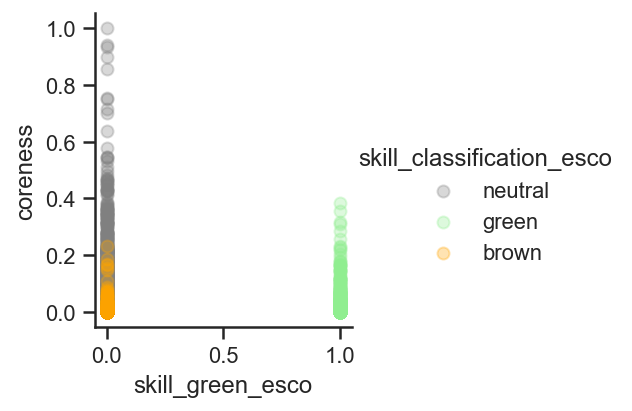

In [62]:
sns.lmplot(
    data=smd_clean,
    x="skill_green_{}".format(clsf),
    y="coreness",
    hue=skill_clsf_col,
    fit_reg=True,
    ci=None,
    hue_order=["neutral", "green", "brown"],
    palette=["grey", "lightgreen", "orange"],
    height=3,
    scatter_kws={"alpha": 0.3}
)

A: Green skills are more central/core than brown skills.

- *green* skills are weakly yet significantly *positively* correlated with skills
coreness
- *brown* skills are weakly yet significantly *negatively* correlated with skills
coreness
- *neutral* skills are *not significantly correlated* with skills coreness at p < 0.05

### 1.2 ESCO Occupations Pillar

Read matched occupation metadata

In [63]:
occ_data = of.combine_occupation_metadata(skills_metadata=smd)

Occupation metadata already loaded.


Read occupation-skills and occupation-similarity matrices

In [64]:
osms = of.occupation_skills_matrix()
osm_weighted = osms["osm_weighted"]
osm_unweighted = osms["osm_unweighted"]

INFO:src.data.framework:Creating occupation-skills matrix.


AttributeError: 'Esco' object has no attribute 'config_data'

**Q: What are the greenest/brownest occupations according to the ESCO GBN labels?**

In [ ]:
occ_share_cols = ["share_green_{}".format(clsf), "share_brown_{}".format(clsf), "share_neutral_{}".format(clsf)]
occ_share_cols

Inspect occupations

In [ ]:
keep_cols = [
    "preferredLabel", occ_share_cols[0], occ_share_cols[1], occ_share_cols[2],
    "conceptUri", "description"
]

(occ_data
.sort_values(occ_share_cols[1], ascending=False)
.loc[:, keep_cols])

Share of 100% neutral occupations

In [ ]:
(len(occ_data.query("share_neutral_{} == 1".format(clsf))) / len(occ_data)) * 100

In [ ]:
occ_data_long = occ_data.melt(
    id_vars=['preferredLabel'],
    value_vars=occ_share_cols,
    var_name=skill_clsf_col,
    value_name="skill_share"

)
occ_data_long[skill_clsf_col] = \
    occ_data_long[skill_clsf_col].str.split("_", expand=True)[1]

In [ ]:
occ_data_long.sort_values("preferredLabel")

In [ ]:
for stat in ["count", "percent", "density"]:
    f, ax = plt.subplots()

    sns.histplot(
        data=occ_data_long,
        # x="preferredLabel",
        x="skill_share",
        hue=skill_clsf_col,
        multiple="stack",
        binwidth=0.05,
        stat=stat,
        hue_order=["green", "brown", "neutral"],
        palette=["lightgreen", "orange", "grey"],
        ax=ax
    )

    sns.despine()
    plt.tight_layout()

Plot occupations with highest g/b/n skill shares.

In [ ]:
plotting_cols = occ_share_cols
n_highest = 20

for sorting_col in plotting_cols:
    occ_data_sub = (occ_data
                    .sort_values(sorting_col, ascending=False)
                    .loc[:, keep_cols]
                    .head(n_highest)[::-1])

    ax = occ_data_sub.plot.barh(
        stacked=True,
        x="preferredLabel",
        color=["lightgreen", "orange", "grey"]
    )

    ax.grid(axis="x", linestyle="-")
    plotting_utils.move_legend_to_top(ax, scale=1, ncol=3)
    sns.despine()

**Q: Which skills are mapped to the top-ranked occupations by GBN type?**

Join skills metadata (GBN classification etc) on occupation-skills mapping

In [ ]:
cols_to_use = of.skills_metadata.columns.difference(of.occupations_to_skills.columns)

occ_skills_mapping_smd_merged = pd.merge(
    left=of.occupations_to_skills,
    right=of.skills_metadata[cols_to_use],
    left_on="skillUri",
    right_on="conceptUri",
    how="left"
)

Join skills metadata to occupation metadata on a many to one basis

In [ ]:
occ_skills_mapping_all_merged = pd.merge(
    left=occ_skills_mapping_smd_merged,
    right=occ_data,
    left_on="occupationUri",
    right_on="conceptUri",
    how="left",
    suffixes=("_skills", "_occs")
)

Select example occupations for GBN separately

In [ ]:
# n occ for ranking
n_occs = 10

# col names
occ_col = "preferredLabel_occs"
skill_col = "preferredLabel_skills"

for sorting_col in plotting_cols:
    # cols to keep in table
    keep_cols = [
        occ_col, skill_col, "relationType", skill_clsf_col,
        "skillType", "reuseLevel", "description_skills",
        sorting_col, "share_green_gtp", "gbn_classification_onet"
    ]

    # get n highest ranking occupations
    occ_ranking = occ_skills_mapping_all_merged.sort_values(
        sorting_col, ascending=False
    ).loc[:, occ_col].unique()
    occ_sel = occ_ranking[:n_occs].tolist()

    # sort and prepare output
    df_out = (occ_skills_mapping_all_merged
     .sort_values(
        by=[sorting_col, occ_col, "relationType", skill_clsf_col],
        ascending=[False, True, True, True]
    ).loc[occ_skills_mapping_all_merged[occ_col].isin(occ_sel), keep_cols]
     .set_index([occ_col, skill_col])
     )

    # store as csv
    df_out.to_csv(
        os.path.join(
            useful_paths.results_dir,
            "validation",
            "gbn_skills_classification",
            "occ_skills_mapping_by_{}_top_{}.csv".format(sorting_col, n_occs)
        ),
        sep=";"
    )

### Comparison of skills and tasks for a small selection (n=5) of green and brown occupations
- selection of occupations with high projected labour demand
- pinpointing them in ONET and ESCO respectively
- examining there tasks and skills (plus metadata)
- getting a qualitative understanding if these different perspectives correspond to each other!

In [ ]:
search = of.occupation_metadata.preferredLabel.str.contains("battery")
of.occupation_metadata.loc[search]

#### Selection of occupations
https://www.bls.gov/ooh/fastest-growing.htm

green occupation                    ¦ growth rate 2020-2030 (%)
Wind turbine service technicians    ¦ 68
Solar photovoltaic installers       ¦ 52

https://www.bls.gov/ooh/installation-maintenance-and-repair/wind-turbine-technicians.htm
https://www.bls.gov/ooh/construction-and-extraction/solar-photovoltaic-installers.htm



In [ ]:
green_esco = [
    "onshore wind farm technician",
    "solar energy technician",
    "automotive battery technician"
]

In [ ]:
of.get_skills_for_occ(id=green_esco[2])

#### Comparison of weighted and unweighted G/B ESCO skill shares
- is this really the right way to weight? not so sure about that...

In [ ]:
gbn_all = of.calc_gbn_shares_skill_based(essential_only=False)

In [ ]:
gbn_core = of.calc_gbn_shares_skill_based(essential_only=True)

In [ ]:
uri_specialist_dentist = 'http://data.europa.eu/esco/occupation/a580e79a-b752-49c1-b033-b5ab2b34bfba'
of.occupations.loc[of.occupations.conceptUri == uri_specialist_dentist]

In [ ]:
gbn_core.loc[gbn_core.conceptUri == uri_specialist_dentist]

In [ ]:
of.get_skills_for_occ(id="specialist dentist")

In [ ]:
gbn_core.describe()

In [ ]:
gbn_all.describe()

In [ ]:
import pingouin as pg

In [ ]:
x = gbn_all.share_green_esco
y = gbn_core.share_green_esco

ax = sns.regplot(
    x=x,
    y=y,
    scatter_kws={"alpha": 0.2}
)

ax.set_xlabel("Greenness (essential + optional)")
ax.set_ylabel("Greenness (essential)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

pg.corr(x, y)

In [ ]:
x = gbn_all.share_brown_esco
y = gbn_core.share_brown_esco

ax = sns.regplot(
    x=x,
    y=y,
    scatter_kws={"alpha": 0.2},
    truncate=False
)

ax.set_xlabel("Brownness (essential + optional)")
ax.set_ylabel("Brownness (essential)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

pg.corr(x, y)

#### Comparison of occupational greenness/brownness between using all skills and essential skills only

In [ ]:
of.combine_occupation_metadata()

Green

In [ ]:
of.occupation_metadata.sort_values("share_green_esco", ascending=False).head(20)

In [ ]:
of.occupation_metadata.sort_values("share_green_esco_ess", ascending=False).head(20)

Brown

In [ ]:
of.occupation_metadata.sort_values("share_brown_esco_ess", ascending=False).head(20)